# **The Momentum Strategy**

## Moving average crossover

A moving average tends to smooth out daily price and shows the underline trend

- **Fast MA**: average of the last 20 days
- **Slow MA**: average of the last 60 days

Signal
- Fast MA crosses above the slow MA -> trend turning upwards -> buy
- Fast MA crosses below the slow MA -> trend turning downwards -> sell

In [2]:
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt

data = yf.download('AAPL', start='2015-01-01', end='2025-01-01')['Close']
data.columns = data.columns.get_level_values(0)
data = data.squeeze() # convert to series
data = data.dropna()
data.head()

[*********************100%***********************]  1 of 1 completed


Date
2015-01-02    24.214897
2015-01-05    23.532719
2015-01-06    23.534939
2015-01-07    23.864950
2015-01-08    24.781895
Name: AAPL, dtype: float64

In [3]:
# Calculate moving averages
fastMA = data.rolling(window=20).mean() # 20 day average
slowMA = data.rolling(window=60).mean() # 20 day average

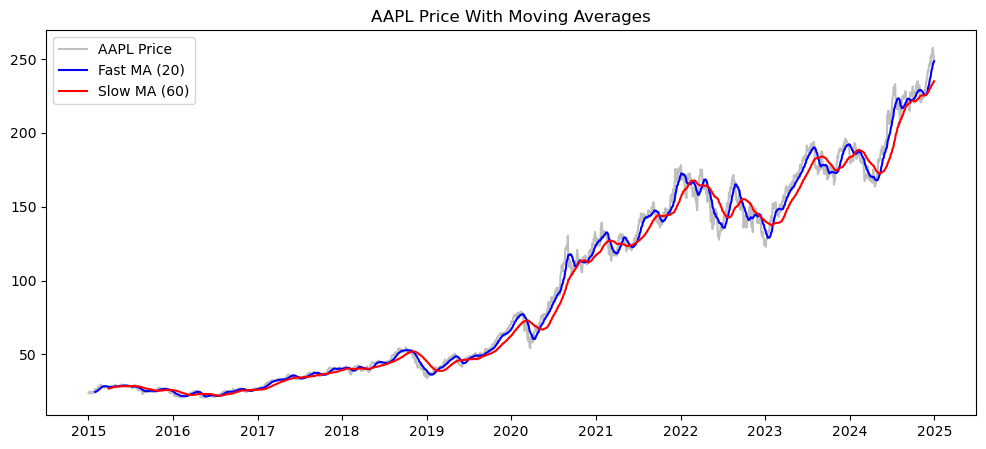

In [4]:
# plot
plt.figure(figsize=(12,5))
plt.plot(data.index,data,label='AAPL Price',alpha=0.5,color='gray')
plt.plot(data.index,fastMA,label='Fast MA (20)',color='blue')
plt.plot(data.index,slowMA,label='Slow MA (60)',color='red')
plt.title('AAPL Price With Moving Averages')
plt.legend()
plt.show()

- **2015 - 2019**: both MAs flat and close together, no momentum
- **2019 - 2020**: price drops sharply, fast MA dips before slow MA, momentum says sell
- **2020 upwards**: strong uptend, fast MA stays above the slow MA, momentum says buy

### Generate Signals

In [48]:
signal = np.where(fastMA > slowMA,1,-1)
# 1 = fast above slow = uptrend = buy
# -1 = fast below slow = downtrend = slow

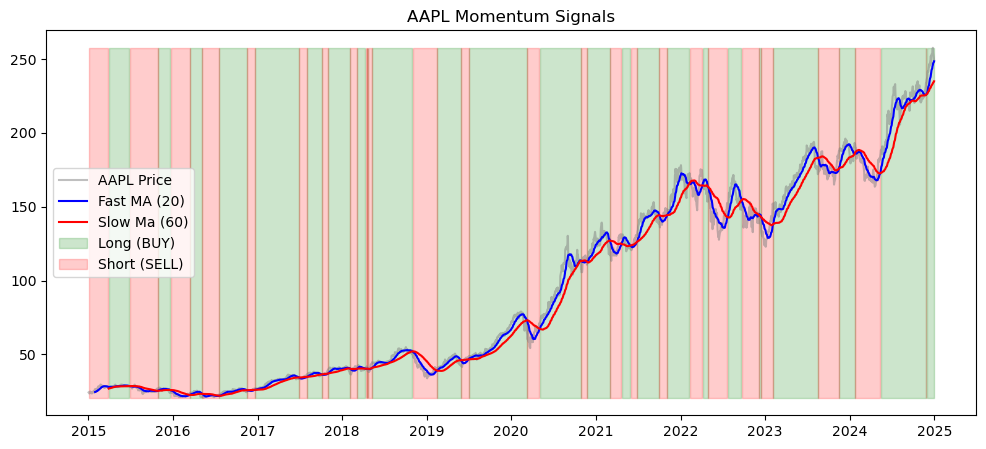

In [50]:
# plots with signal highlighted
plt.figure(figsize=(12,5))
plt.plot(data.index, data, label="AAPL Price", alpha=0.5, color="gray")
plt.plot(data.index, fastMA, label="Fast MA (20)", color="blue")
plt.plot(data.index, slowMA, label="Slow Ma (60)", color="red")

# Highlight buy zones green, sell zones red
plt.fill_between(data.index, data.min(), data.max(),
                 where=signal==1,alpha=0.2,
                 color="green", label="Long (BUY)")
plt.fill_between(data.index, data.min(), data.max(),
                 where=signal==-1,alpha=0.2,
                 color="red", label="Short (SELL)")
plt.title('AAPL Momentum Signals')
plt.legend()
plt.show()

### Calculate returns

Yesterdays signal * todays return = todays profit

- position = 1 -> you are long -> you profit when AAPL rises
- position = -1 -> you are short -> you profit when AAPL falls

In [51]:
## shift signal by 1 to avoid look ahead bias
signal = np.roll(signal,1) # yesterday's signal
signal[0] = 0 # no position on the first day

In [53]:
# daily returns
dailyRet = data.pct_change().fillna(0)

# strategy returns
stratRet = signal * dailyRet

# cummulative returns 
cumRet = (1+stratRet).cumprod() - 1
cumRetBuyHold = (1+ dailyRet).cumprod() - 1

In [54]:
# Performace metrices
sharpeRatio = np.sqrt(252) * np.mean(stratRet) / np.std(stratRet)

# Max drawdown
def calculateMaxDD(cumret):
    cumret = np.array(cumret)
    highwatermark  = np.zeros(cumret.shape)
    drawdown       = np.zeros(cumret.shape)
    drawdownduration = np.zeros(cumret.shape)
    for t in np.arange(1, cumret.shape[0]):
        highwatermark[t] = np.maximum(highwatermark[t-1], cumret[t])
        drawdown[t] = (1+cumret[t])/(1+highwatermark[t])-1
        if drawdown[t] == 0:
            drawdownduration[t] = 0
        else:
            drawdownduration[t] = drawdownduration[t-1]+1
    return np.min(drawdown), np.max(drawdownduration)

maxDD, maxDDD = calculateMaxDD(cumRet)

In [55]:
print(f"Sharpe Ratio:          {sharpeRatio:.4f}")
print(f"Max Drawdown:          {maxDD*100:.2f}%")
print(f"Max Drawdown Duration: {maxDDD:.0f} days")
print(f"Total Return:          {cumRet.iloc[-1]*100:.2f}%")
print(f"Buy & Hold Return:     {cumRetBuyHold.iloc[-1]*100:.2f}%")

Sharpe Ratio:          0.1935
Max Drawdown:          -57.24%
Max Drawdown Duration: 1311 days
Total Return:          15.60%
Buy & Hold Return:     928.54%


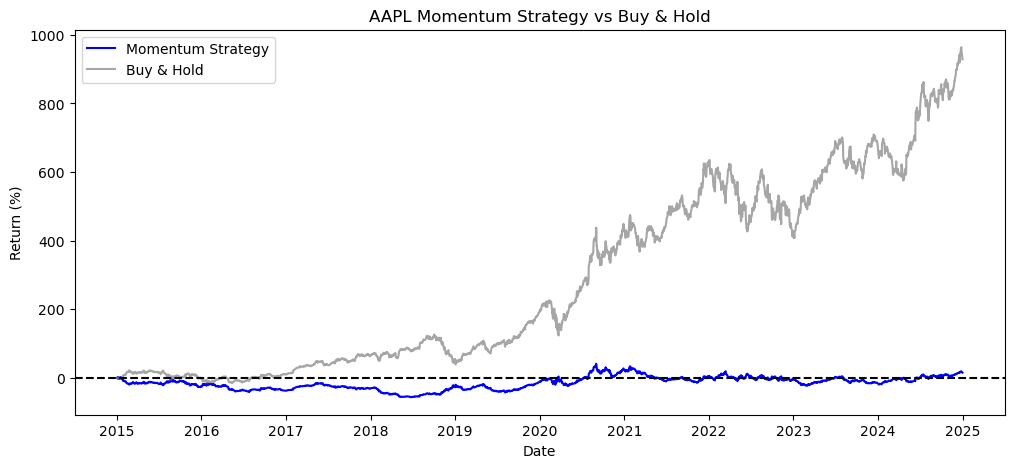

In [56]:
# Plot cumulative returns
plt.figure(figsize=(12,5))
plt.plot(data.index, cumRet*100, label='Momentum Strategy', color='blue')
plt.plot(data.index, cumRetBuyHold*100, label='Buy & Hold', color='gray', alpha=0.7)
plt.axhline(0, color='black', linestyle='--')
plt.title('AAPL Momentum Strategy vs Buy & Hold')
plt.ylabel('Return (%)')
plt.xlabel('Date')
plt.legend()
plt.show()

Sharpe Ratio: 0.1935, terrible. 

Almost no return for the amount of risk taken. Our pair trading strategy at 0.43 was weak — this is worse.
Max Drawdown: -57.24%

Catastrophic. At some point you would have lost more than half your money waiting for recovery. Compare this to pair trading's -3.79% — night and day difference.
Max Drawdown Duration: 1311 days

Over 5 years underwater. The entire backtest period is 5 years — meaning you were basically never consistently above your peak.

Total Return: 15.60% vs Buy & Hold: 928.54%

This is the killer. Simply buying AAPL and doing absolutely nothing returned 928% while your sophisticated momentum strategy returned 15%.